# Analyzing coincident detections

Code to plot both the lightcurve and show the relevant images of a detection

In [12]:
import os
import sys

path_add = r"C:\Users\GreenBird\Documents\GitHub\ColibriPipeline\ColibriPipeline"
if path_add not in sys.path:
    sys.path.append(path_add)

import colibri_image_reader as cir

In [5]:
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd

green_archive = r"D:\LongTermStorage\Pipeline_Testing\ColibriArchive\2024-10-19"
blue_archive = r"B:\LongTermStorage\PipelineTesting\ColibriArchive\2024-10-19"
# red_archive = r"R:\LongTermStorage\Pipeline_Testing\ColibriArchive\2024-10-19"

# Find all the files in each directory that begin with "det" and end with ".txt"
green_files = [f for f in os.listdir(green_archive) if f.startswith("det") and f.endswith(".txt")]
blue_files = [f for f in os.listdir(blue_archive) if f.startswith("det") and f.endswith(".txt")]
# red_files = [f for f in os.listdir(red_archive) if f.startswith("det") and f.endswith(".txt")]

# print the first green file just to check
print(green_files[0])

det_2024-10-19_235117_561239000_star45_GREENBIRD.txt


In [19]:
def parse_header(file_path):
    metadata = {}
    with open(file_path, 'r') as file:
        for line in file:
            line = line.strip()
            if line.startswith("#"):
                # Remove the leading '#' and strip whitespace
                line_content = line[1:].strip()
                if ":" in line_content:
                    # Split key-value pairs
                    key, value = map(str.strip, line_content.split(":", 1))
                    metadata[key] = value
            else:
                # Stop parsing header when non-commented lines are reached
                break

    return metadata

In [23]:
from datetime import datetime, timedelta

# Example of extracting and printing the time part
time_part_example = green_files[0].split("_")[2:4]  # first part is HHMMSS, second part is fraction of seconds
print(time_part_example)

# For every file, read the time parts, create tuples for files in green and blue that occur in the same time within 0.1 seconds
coincident_detections = []  # list of tuples (green_file, blue_file)
for green_file in green_files:
    # Extract the time part from the filename
    time_part = green_file.split("_")[2:4]  # first part is HHMMSS, second part is fraction of seconds
    time_str = time_part[0] + "." + time_part[1][:6]  # combine HHMMSS and first 6 digits of fraction of seconds
    green_time = datetime.strptime(time_str, "%H%M%S.%f")  # convert to datetime object

    # Find the corresponding blue file with the same time part
    for blue_file in blue_files:
        blue_time_part = blue_file.split("_")[2:4]
        blue_time_str = blue_time_part[0] + "." + blue_time_part[1][:6]  # truncate to 6 digits
        blue_time = datetime.strptime(blue_time_str, "%H%M%S.%f")  # convert to datetime object

        # Compare the times with a tolerance of 0.1 seconds
        if abs((green_time - blue_time).total_seconds()) < 1.0:


            # If they are within 0.1 seconds, get the metadata, compare x, y pixel positions and add to list if they are within 50 pixels
            green_metadata = parse_header(os.path.join(green_archive, green_file))
            blue_metadata = parse_header(os.path.join(blue_archive, blue_file))

            star_coords_green = [float(coord) for coord in green_metadata['Star Coords'].split(" ")]
            star_coords_blue = [float(coord) for coord in blue_metadata['Star Coords'].split(" ")]

            # Calculate the distance between the two star coordinates
            distance = np.sqrt((star_coords_green[0] - star_coords_blue[0])**2 + (star_coords_green[1] - star_coords_blue[1])**2)
            # Check if the distance is within 50 pixels
            if distance < 100:
                # If they are within 50 pixels, add to the list of coincident detections
                coincident_detections.append((green_file, blue_file))


print(f"Number of green files: {len(green_files)}")
print(f"Number of blue files: {len(blue_files)}")
print(f"Number of coincident detections: {len(coincident_detections)}")

['235117', '561239000']
Number of green files: 933
Number of blue files: 741
Number of coincident detections: 3


In [24]:
green_file = os.path.join(green_archive, coincident_detections[0][0])
print(f"Parsing metadata from: {green_file}")
green_metadata = parse_header(green_file)
print(green_metadata)
print(green_metadata['Star Coords'])

Parsing metadata from: D:\LongTermStorage\Pipeline_Testing\ColibriArchive\2024-10-19\det_2024-10-19_235117_561239000_star45_GREENBIRD.txt
{'Event File': 'D:\\LongTermStorage\\Pipeline_Testing\\ColibriData\\20241019\\20241019_23.50.27.585\\field11_25ms-W_0001995.rcd', 'Star Coords': '1720.611906 1799.521355', 'DATE-OBS': '2024-10-19T23:51:17.561239000', 'Telescope': 'GREENBIRD', 'Field': 'field11', 'significance': '7.603', 'Raw lightcurve std': '179.0982', 'Raw lightcurve mean': '633.4636', 'Convolution background std': '0.9259', 'Convolution background mean': '0.0198', 'Convolution minimal value': '-7.0202'}
1720.611906 1799.521355


Green file: det_2024-10-20_054256_425744000_star60_GREENBIRD.txt
Blue file: det_2024-10-20_054255_590284000_star59_BLUEBIRD.txt


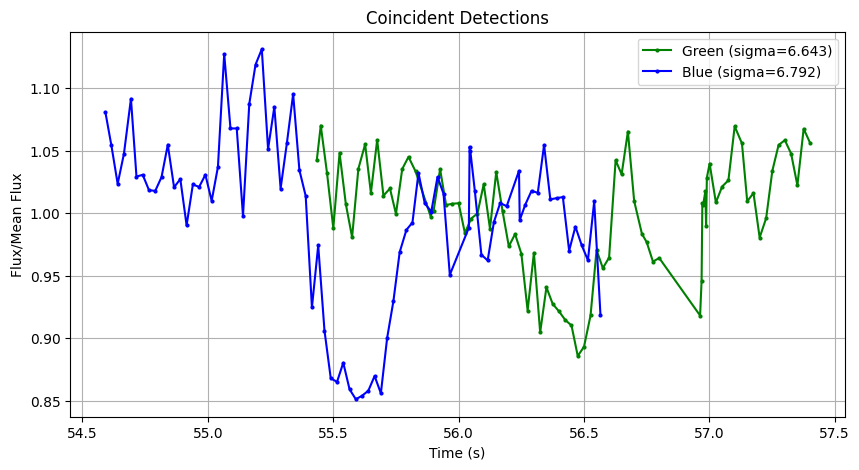

Star coords green: [229.086364, 818.601634]
Star coords blue: [232.275373, 727.360166]


C:\Users\GreenBird\AppData\Local\Temp\ipykernel_1276\1812531830.py:56: RuntimeWarning: divide by zero encountered in log
  ax[0].imshow(np.log(rcd_images_green[0]), cmap='gray')


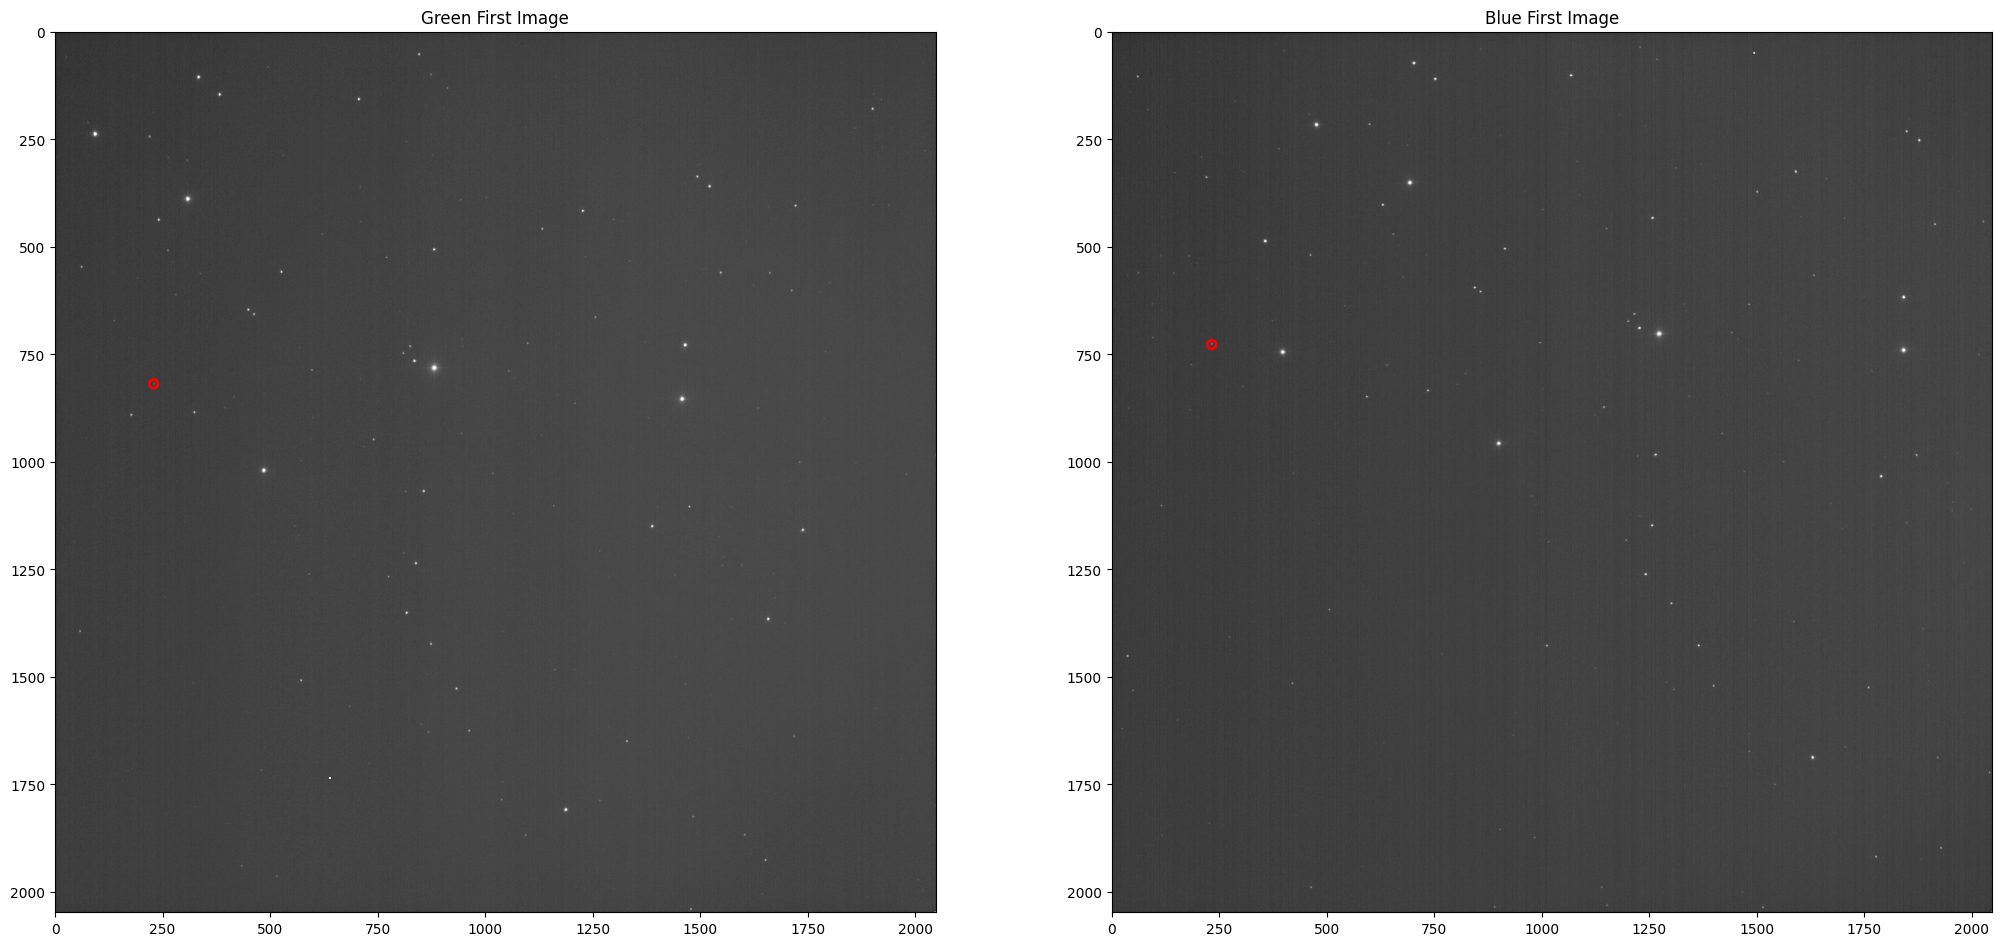

C:\Users\GreenBird\AppData\Local\Temp\ipykernel_1276\1812531830.py:67: RuntimeWarning: divide by zero encountered in log
  ax[0].imshow(np.log(rcd_images_green[0]), cmap='gray')


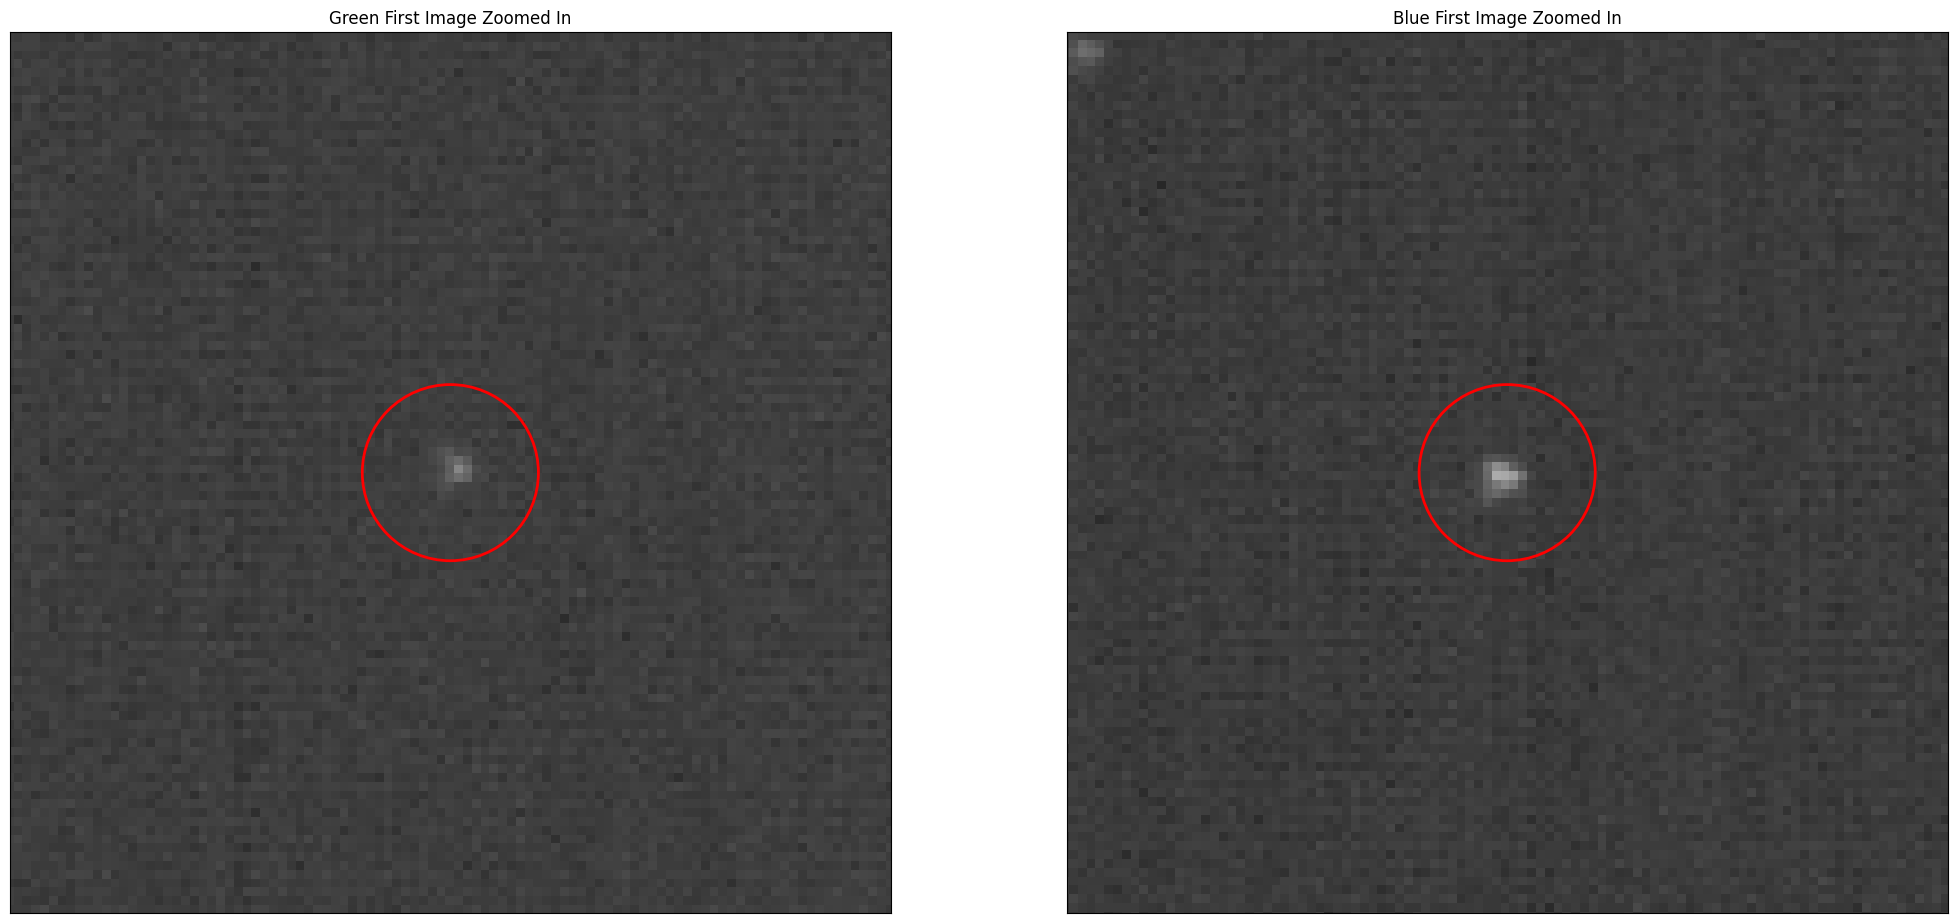

In [40]:
import pandas as pd

# Read the data from the files and plot the data

# df = pd.read_csv(os.path.join(data_loc, f), delim_whitespace=True, skiprows=lambda x: x< 19, names=['filename', 'time', 'flux', 'conv_flux'])

detect_idx = 2
data_green = pd.read_csv(os.path.join(green_archive, coincident_detections[detect_idx][0]), delim_whitespace=True, skiprows=lambda x: x< 19, names=['filename', 'time', 'flux', 'conv_flux'])
data_blue = pd.read_csv(os.path.join(blue_archive, coincident_detections[detect_idx][1]), delim_whitespace=True, skiprows=lambda x: x< 19, names=['filename', 'time', 'flux', 'conv_flux'])
green_metadata = parse_header(os.path.join(green_archive, coincident_detections[detect_idx][0]))
blue_metadata = parse_header(os.path.join(blue_archive, coincident_detections[detect_idx][1]))

green_signifiance = float(green_metadata['significance'])
blue_signifiance = float(blue_metadata['significance'])



# print the filenames
print(f"Green file: {coincident_detections[detect_idx][0]}")
print(f"Blue file: {coincident_detections[detect_idx][1]}")

# plot the flux for both green and blue files
plt.figure(figsize=(10, 5))
plt.plot(data_green['time'], data_green['flux']/np.mean(data_green['flux']), label=f'Green (sigma={green_signifiance})', color='green', marker='o', markersize=2)
plt.plot(data_blue['time'], data_blue['flux']/np.mean(data_blue['flux']), label=f'Blue (sigma={blue_signifiance})', color='blue', marker='o', markersize=2)

# xlim around the middle time value 
# middle_time = (data_green['time'].max() + data_green['time'].min()) / 2
# plt.xlim(middle_time - 1, middle_time + 0.5)


plt.xlabel('Time (s)')
plt.ylabel('Flux/Mean Flux')
plt.title('Coincident Detections')
plt.legend()
plt.grid()
plt.show()

# Plot the rcd images for both green and blue files
green_detection_filepaths = data_green['filename'].values
blue_detection_filepaths = data_blue['filename'].values
blue_detection_filepaths = [f.replace('D:', 'B:') for f in blue_detection_filepaths]
rcd_images_green = cir.importFramesRCD(green_detection_filepaths,30, 10)[0]
rcd_images_blue = cir.importFramesRCD(blue_detection_filepaths,30, 10)[0]


# First make a figure circling the star coords using the first image in the list
star_coords_green = [float(coord) for coord in green_metadata['Star Coords'].split(" ")]
star_coords_blue = [float(coord) for coord in blue_metadata['Star Coords'].split(" ")]
print(f"Star coords green: {star_coords_green}")
print(f"Star coords blue: {star_coords_blue}")



fig, ax = plt.subplots(1, 2, figsize=(25, 20))
ax[0].imshow(np.log(rcd_images_green[0]), cmap='gray')
ax[0].add_patch(plt.Circle(star_coords_green, 10, color='red', fill=False, linewidth=2))
ax[0].set_title('Green First Image')

ax[1].imshow(np.log(rcd_images_blue[0]), cmap='gray')
ax[1].add_patch(plt.Circle(star_coords_blue, 10, color='red', fill=False, linewidth=2))
ax[1].set_title('Blue First Image')
plt.show()

# zoom in around the star coords
fig, ax = plt.subplots(1, 2, figsize=(25, 20))
ax[0].imshow(np.log(rcd_images_green[0]), cmap='gray')
ax[0].add_patch(plt.Circle(star_coords_green, 10, color='red', fill=False, linewidth=2))
ax[0].set_xlim(star_coords_green[0]-50, star_coords_green[0]+50)
ax[0].set_ylim(star_coords_green[1]-50, star_coords_green[1]+50)
ax[0].set_title('Green First Image Zoomed In')
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[1].imshow(np.log(rcd_images_blue[0]), cmap='gray')
ax[1].add_patch(plt.Circle(star_coords_blue, 10, color='red', fill=False, linewidth=2))
ax[1].set_xlim(star_coords_blue[0]-50, star_coords_blue[0]+50)
ax[1].set_ylim(star_coords_blue[1]-50, star_coords_blue[1]+50)
ax[1].set_title('Blue First Image Zoomed In')
ax[1].set_xticks([])
ax[1].set_yticks([])
plt.show()


# Occultation images

In [52]:
from datetime import datetime

def plot_images_in_grid(images, times, star_coords, zoom_size=50):
    """
    Plots images in a 3x3 grid, zoomed around the star's coordinates, with times in the titles.
    
    Parameters:
        images (list of np.ndarray): List of image arrays.
        times (list of str): List of times corresponding to each image (as strings).
        star_coords (tuple): Coordinates of the star (x, y).
        zoom_size (int): Half the size of the zoomed region around the star.
    """
    num_images = len(images)
    for i in range(0, num_images, 9):
        fig, axes = plt.subplots(3, 3, figsize=(10, 10))
        fig.suptitle(f"Images {i+1} to {min(i+9, num_images)}", fontsize=16)
        
        for j, ax in enumerate(axes.flat):
            if i + j < num_images:
                image = images[i + j]
                time = times[i + j]  # Use the string time directly
                x, y = int(star_coords[0]), int(star_coords[1])
                
                # Extract zoomed region
                zoomed_image = image[max(0, y-zoom_size):y+zoom_size, max(0, x-zoom_size):x+zoom_size]
                
                ax.imshow(zoomed_image, cmap='gray', origin='lower')
                ax.set_title(f"Image {i + j + 1}\nTime: {time}")
                ax.axis('off')
            else:
                ax.axis('off')  # Hide unused subplots
        
        plt.tight_layout()
        plt.subplots_adjust(top=0.9)  # Adjust for the title
        plt.show()

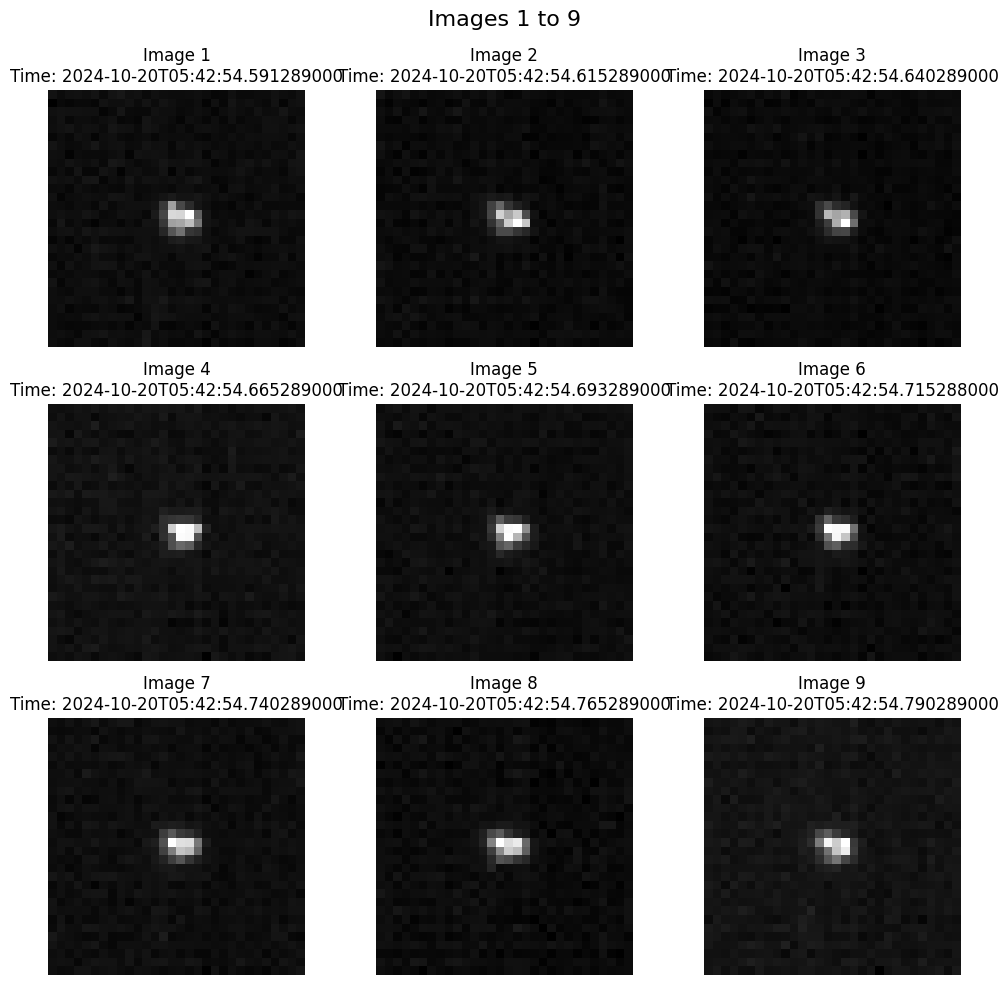

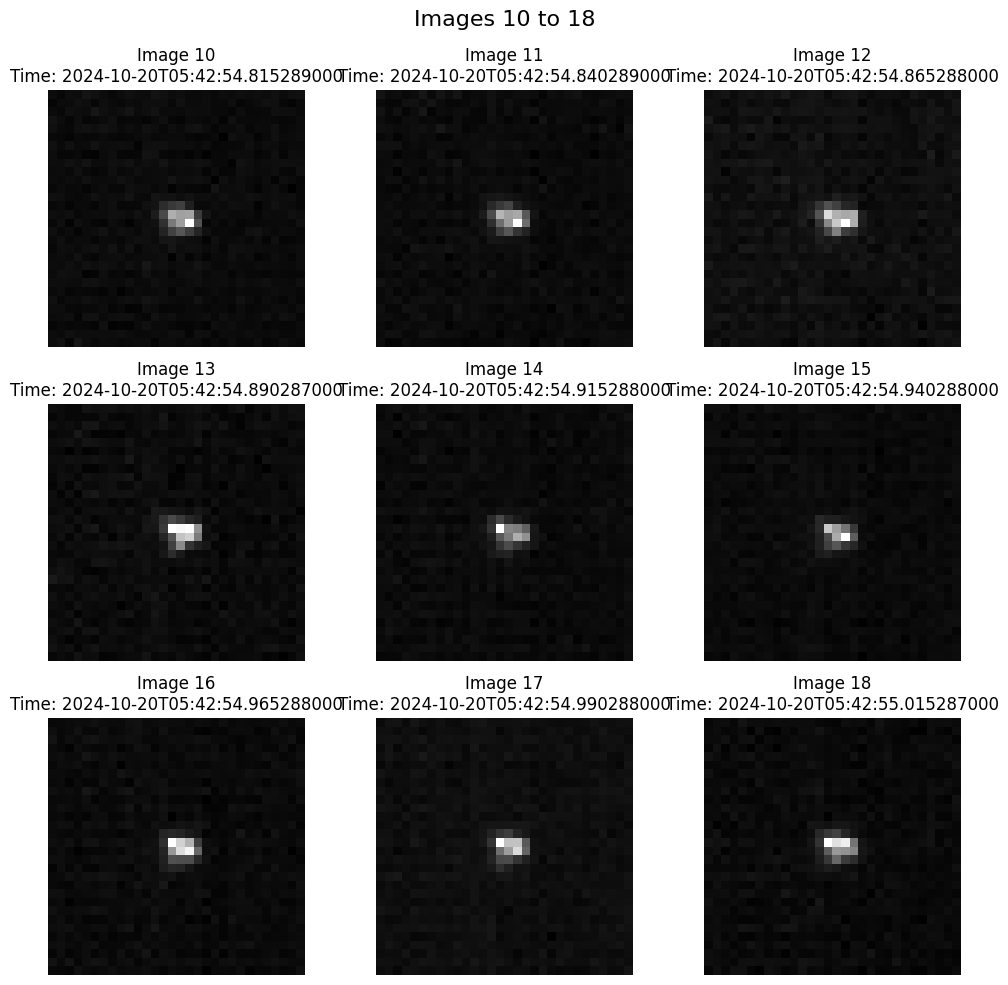

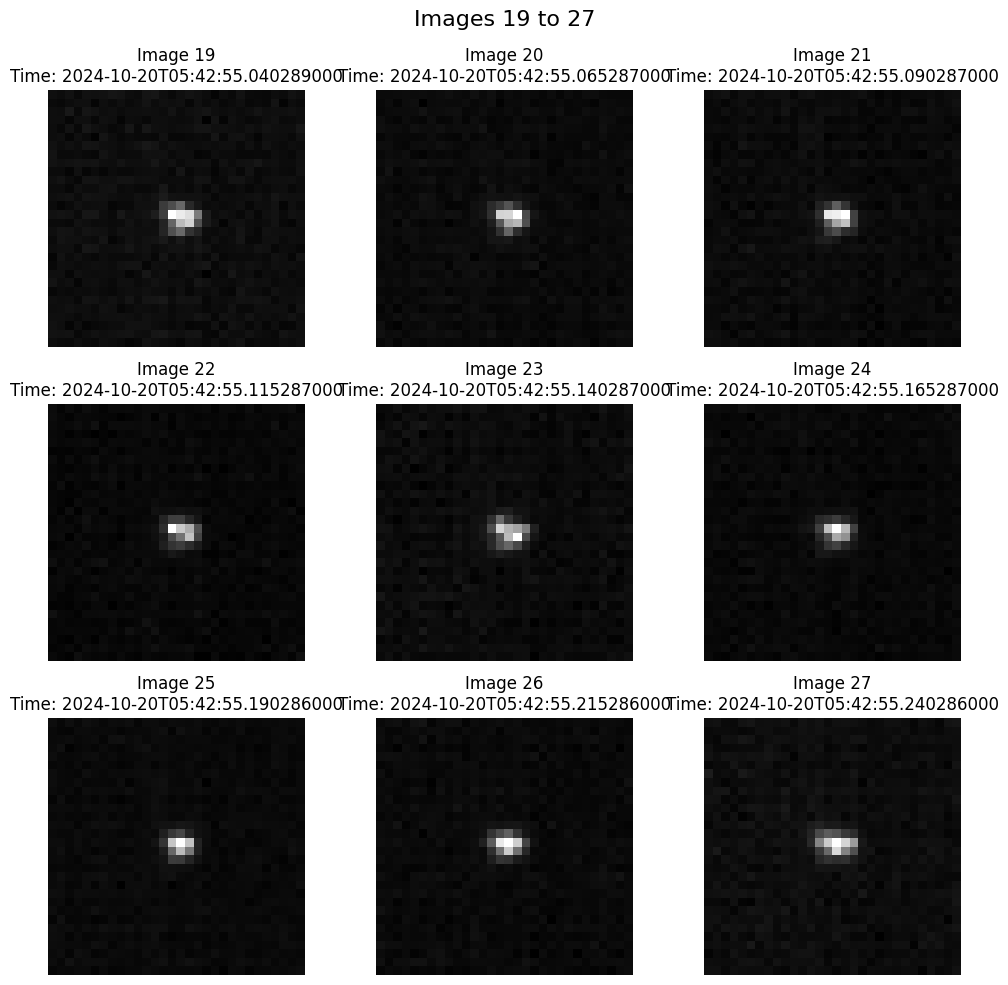

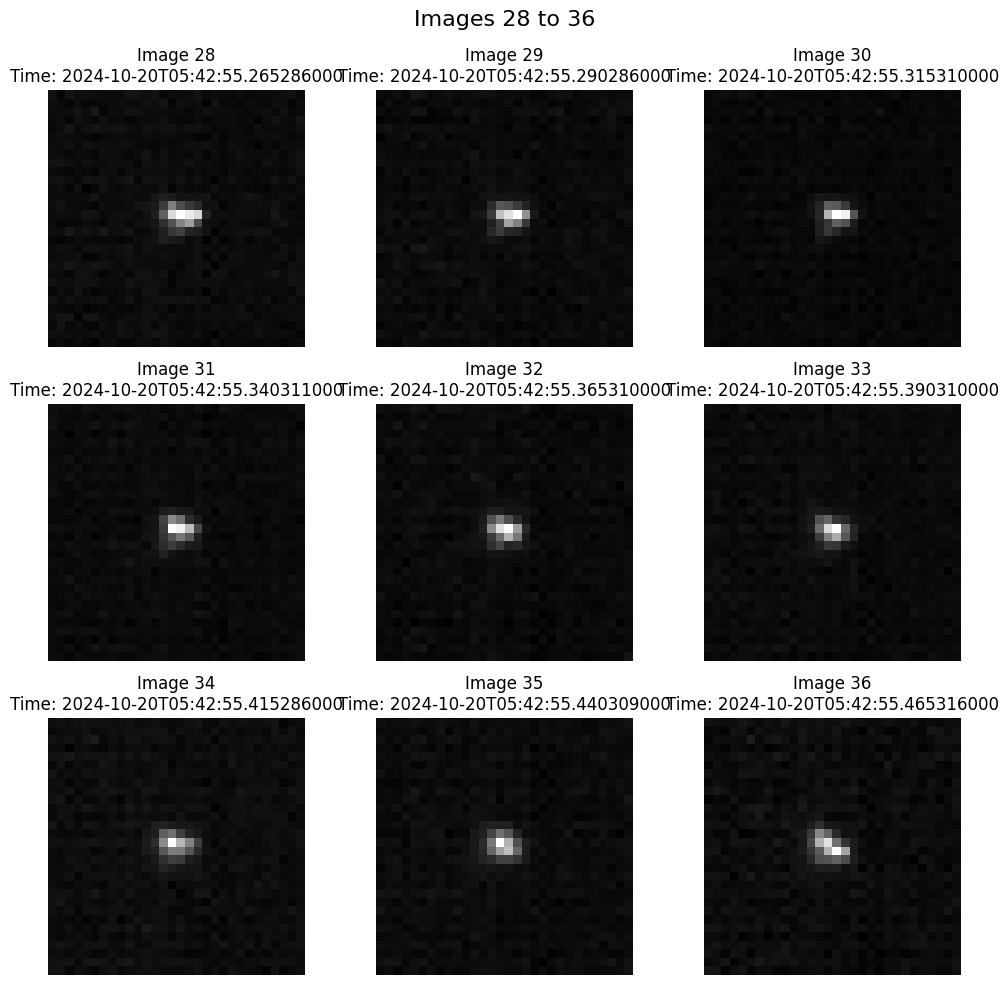

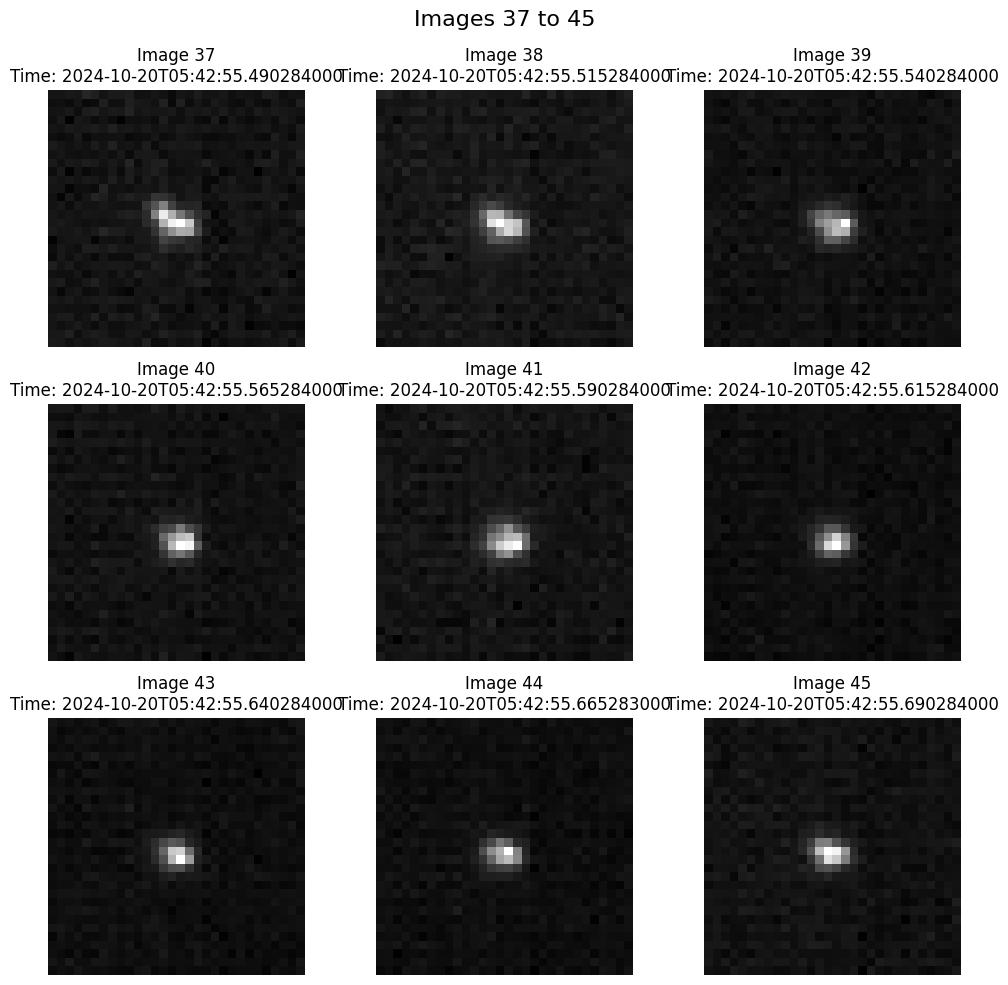

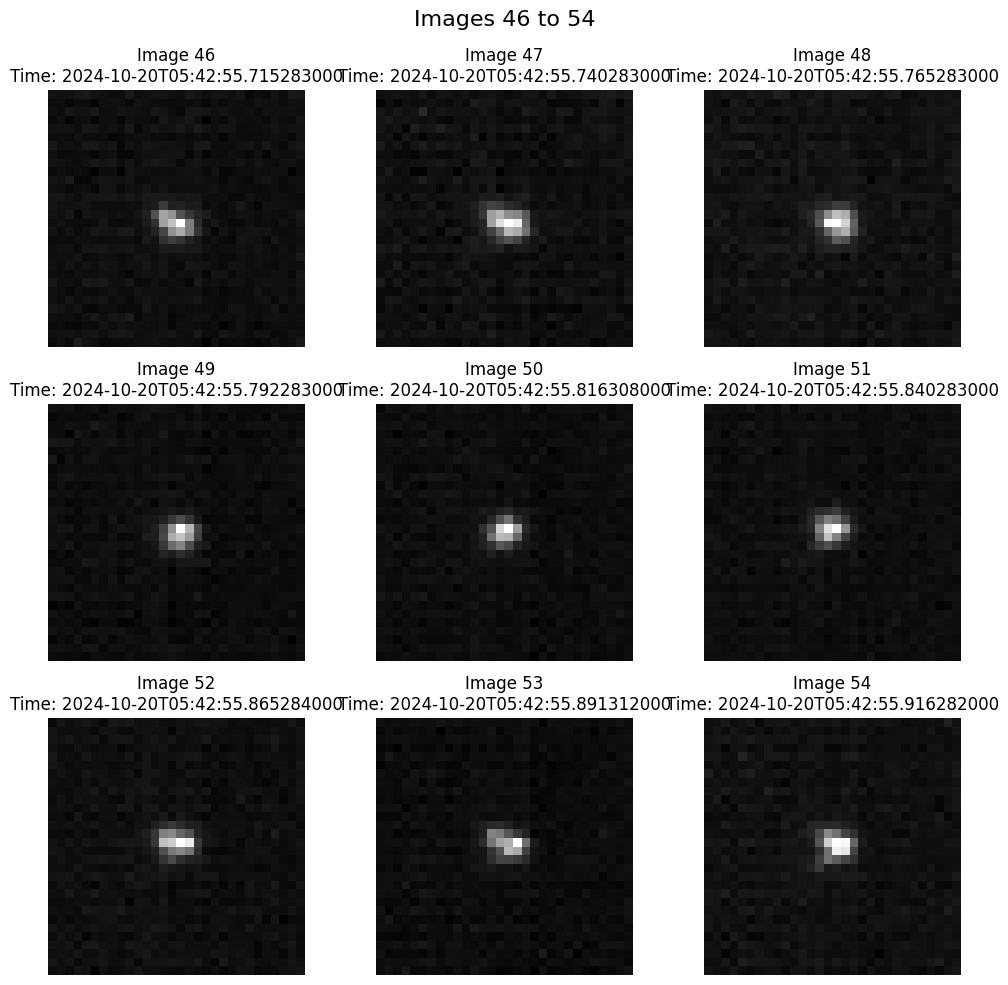

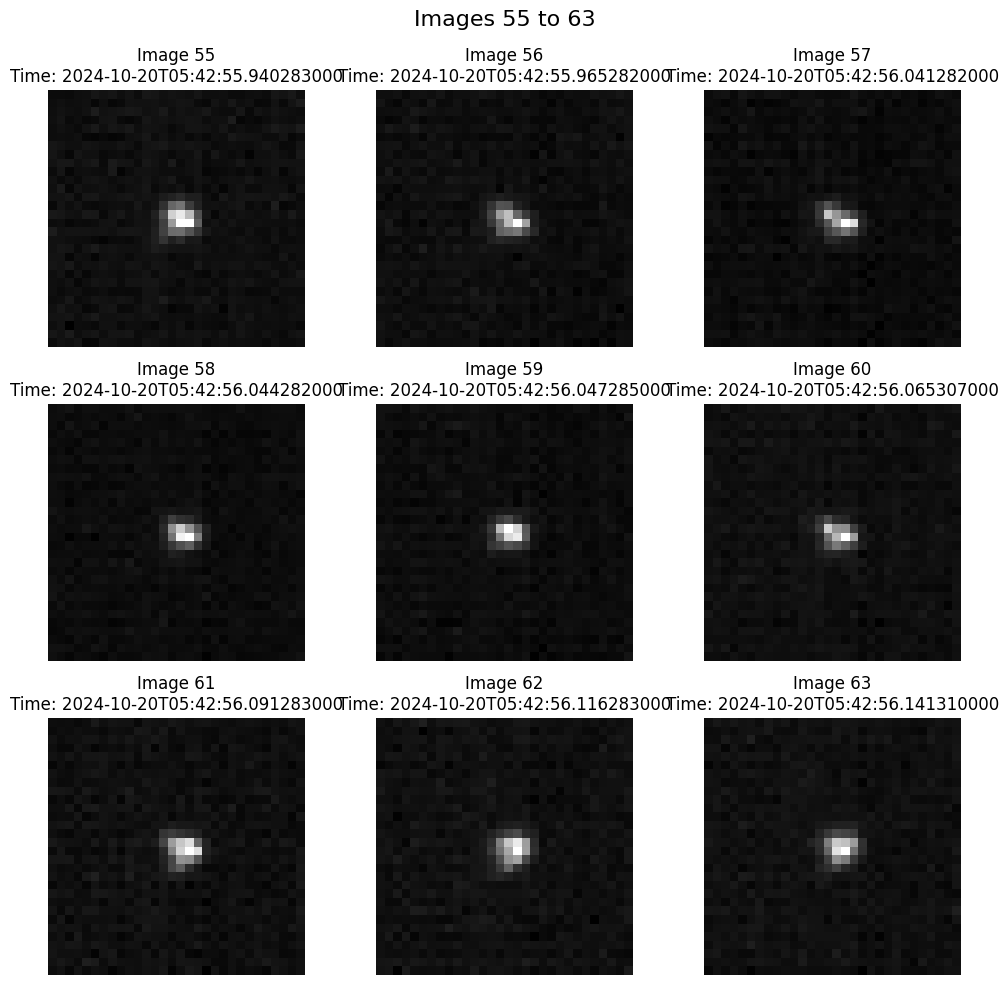

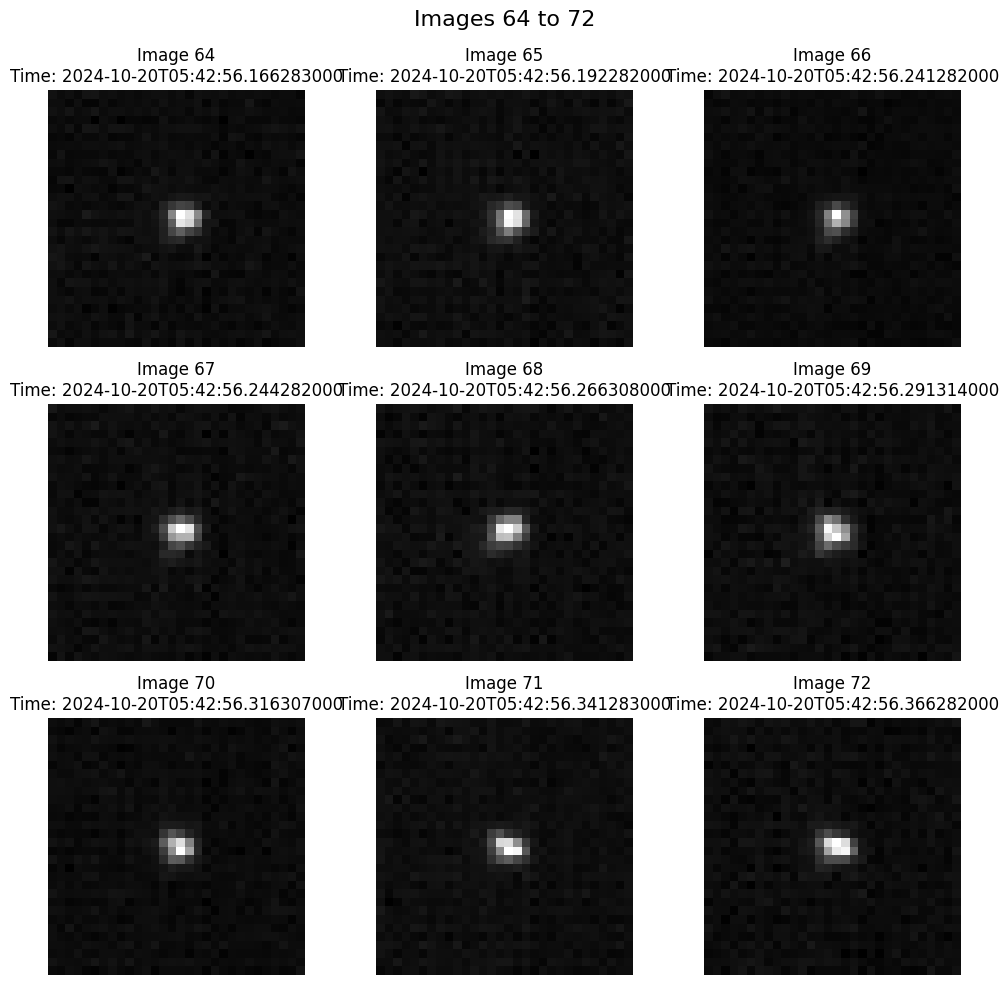

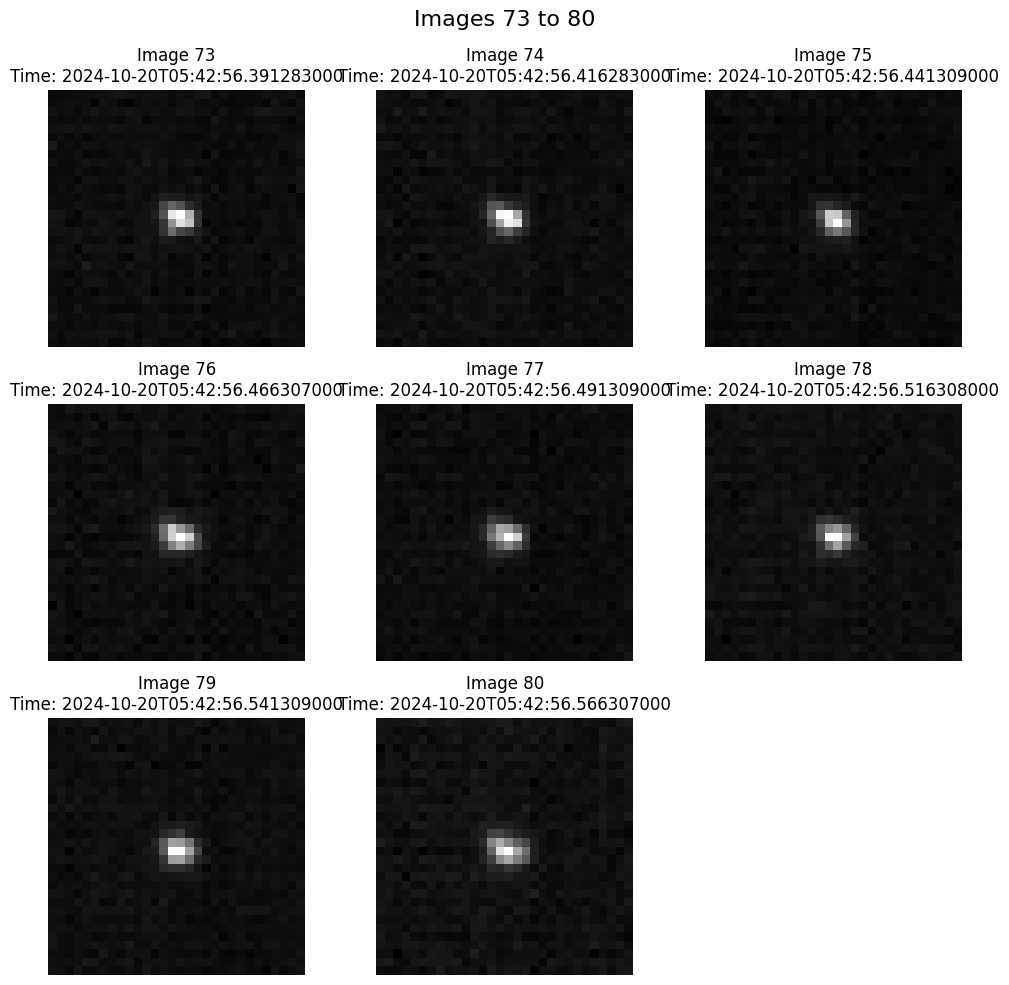

In [55]:
all_rcd_images_blue, times = cir.importFramesRCD(blue_detection_filepaths,0, 80)
star_coords_blue = [float(coord) for coord in blue_metadata['Star Coords'].split(" ")]


# Example usage
# Assuming `all_rcd_images_blue` is a list of 2D numpy arrays representing the images
# and `star_coords_blue` is a tuple (x, y) of the star's coordinates
plot_images_in_grid(all_rcd_images_blue, times, star_coords_blue, zoom_size=15)
